# HSE Incident Forecast — Model Comparison

Сравниваем 6 подходов к прогнозированию частоты инцидентов по месяцам:

| # | Модель | Тип |
|---|---|---|
| 1 | Linear Regression + Seasonality | Baseline |
| 2 | ARIMA (auto order) | Classical TS |
| 3 | ETS / Holt-Winters | Classical TS |
| 4 | Prophet | Modern TS |
| 5 | LSTM | Deep Learning |
| 6 | Gradient Boosting (features) | ML |

**Метрики:** MAE, RMSE, MAPE, R²  
**Протокол:** walk-forward validation (последние 6 месяцев — тест)

In [1]:
# ── Install dependencies (run once) ─────────────────────────────────────────
!pip install prophet scikit-learn statsmodels tensorflow openpyxl

  Using cached scikit_learn-1.8.0-cp313-cp313-win_amd64.whl.metadata (11 kB)
  Using cached statsmodels-0.14.6-cp313-cp313-win_amd64.whl.metadata (9.8 kB)
  Using cached openpyxl-3.1.5-py2.py3-none-any.whl.metadata (2.5 kB)
  Using cached matplotlib-3.10.8-cp313-cp313-win_amd64.whl.metadata (52 kB)
  Using cached pandas-3.0.1-cp313-cp313-win_amd64.whl.metadata (19 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl.metadata (57 kB)
  Using cached importlib_resources-6.5.2-py3-none-any.whl.metadata (3.9 kB)
  Using cached scipy-1.17.1-cp313-cp313-win_amd64.whl.metadata (60 kB)
  Using cached joblib-1.5.3-py3-none-any.whl.metadata (5.5 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
  Using cached patsy-1.0.2-py2.py3-none-any.whl.metadata (3.6 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached setuptools-82.0.1-py3-none-any.whl.metadata (6.5 kB)
  Using cached typing_extensions-4.15.0-py3-none-any.whl.metadata (3.3 kB)
  Usi

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

# ── Load data ────────────────────────────────────────────────────────────────
DATA_PATH = Path('../incidents.xlsx')
df_raw = pd.read_excel(DATA_PATH)

df_raw['date'] = pd.to_datetime(df_raw['Дата возникновения происшествия'], errors='coerce')
df_raw = df_raw.dropna(subset=['date'])
df_raw['month'] = df_raw['date'].dt.to_period('M')

monthly = (
    df_raw.groupby('month')
    .size()
    .reset_index(name='count')
    .sort_values('month')
)
monthly['ds'] = monthly['month'].dt.to_timestamp()
monthly['t'] = np.arange(len(monthly))

print(f'Months in dataset: {len(monthly)}')
print(monthly.tail())

Months in dataset: 14
      month  count         ds   t
9   2025-10     18 2025-10-01   9
10  2025-11      3 2025-11-01  10
11  2025-12      6 2025-12-01  11
12  2026-01      7 2026-01-01  12
13  2026-02      5 2026-02-01  13


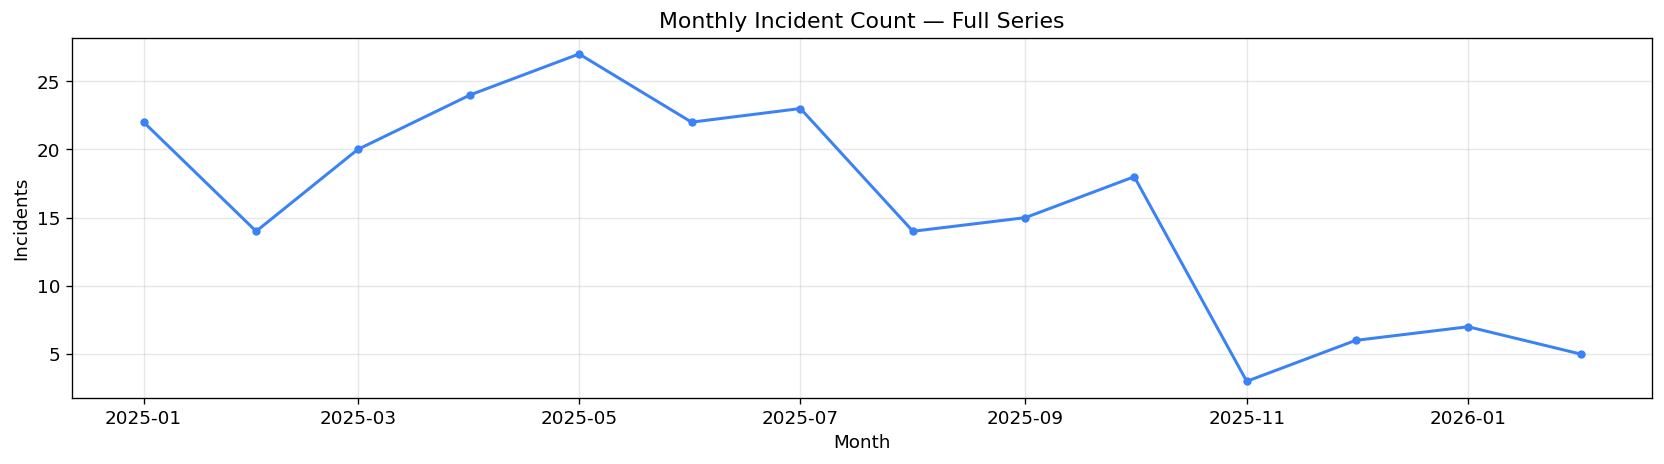

In [3]:
# ── Visualize raw series ─────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(monthly['ds'], monthly['count'], marker='o', markersize=4, linewidth=1.8, color='#3b82f6')
ax.set_title('Monthly Incident Count — Full Series')
ax.set_xlabel('Month')
ax.set_ylabel('Incidents')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# ── Train / Test split ───────────────────────────────────────────────────────
TEST_MONTHS = 6
n = len(monthly)
train = monthly.iloc[:n - TEST_MONTHS].copy()
test  = monthly.iloc[n - TEST_MONTHS:].copy()

y_train = train['count'].values.astype(float)
y_test  = test['count'].values.astype(float)

print(f'Train: {len(train)} months  |  Test: {len(test)} months')
print(f'Test period: {test["ds"].iloc[0].date()} — {test["ds"].iloc[-1].date()}')

Train: 8 months  |  Test: 6 months
Test period: 2025-09-01 — 2026-02-01


In [5]:
# ── Metric helpers ───────────────────────────────────────────────────────────
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metrics(y_true, y_pred, name=''):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)
    mae   = mean_absolute_error(y_true, y_pred)
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mask  = y_true != 0
    mape  = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    r2    = r2_score(y_true, y_pred)
    return {'Model': name, 'MAE': round(mae,2), 'RMSE': round(rmse,2), 'MAPE%': round(mape,1), 'R²': round(r2,3)}

results = []

## 1. Baseline — Linear Regression + Sine Seasonality

In [6]:
from sklearn.linear_model import LinearRegression

X_tr = train['t'].values.reshape(-1, 1)
lr = LinearRegression().fit(X_tr, y_train)
trend_tr = lr.predict(X_tr)
residuals = y_train - trend_tr

# Fit sine on residuals
best_amp, best_phase, best_period = 0.0, 0.0, 12
for period in [12, 6]:
    for phase in np.linspace(0, 2*np.pi, 40):
        amp = np.std(residuals)
        fitted = amp * np.sin(2*np.pi * train['t'].values / period + phase)
        if np.mean((residuals - fitted)**2) < np.mean(residuals**2):
            best_amp, best_phase, best_period = amp, phase, period

def lr_predict(t_vals):
    return (lr.predict(t_vals.reshape(-1,1)).flatten()
            + best_amp * np.sin(2*np.pi * t_vals / best_period + best_phase))

t_test = test['t'].values
pred_lr = np.maximum(0, lr_predict(t_test))
results.append(metrics(y_test, pred_lr, 'LinReg + Sine'))
print(results[-1])

{'Model': 'LinReg + Sine', 'MAE': 11.58, 'RMSE': np.float64(12.39), 'MAPE%': np.float64(226.4), 'R²': -4.058}


## 2. ARIMA (auto order by AIC)

In [7]:
from statsmodels.tsa.arima.model import ARIMA

best_aic, best_res, best_order = np.inf, None, (1,1,1)
for p in range(3):
    for d in range(2):
        for q in range(3):
            try:
                res = ARIMA(y_train, order=(p,d,q)).fit()
                if res.aic < best_aic:
                    best_aic, best_res, best_order = res.aic, res, (p,d,q)
            except Exception:
                pass

fc = best_res.get_forecast(steps=TEST_MONTHS)
fc_mean = np.asarray(fc.predicted_mean)
pred_arima = np.maximum(0, fc_mean)

results.append(metrics(y_test, pred_arima, f'ARIMA{best_order}'))
print(f'Best order: {best_order}  AIC: {best_aic:.1f}')
print(results[-1])

d:\dev\AstanaHub\Projects\HSE2.0\.venvml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


Best order: (0, 1, 0)  AIC: 46.4
{'Model': 'ARIMA(0, 1, 0)', 'MAE': 6.67, 'RMSE': np.float64(7.44), 'MAPE%': np.float64(134.8), 'R²': -0.824}


d:\dev\AstanaHub\Projects\HSE2.0\.venvml\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


## 3. Exponential Smoothing — Holt-Winters

In [8]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# Try additive seasonality if enough data, else simple Holt
if len(y_train) >= 24:
    ets = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    model_name = 'ETS Holt-Winters'
elif len(y_train) >= 12:
    ets = ExponentialSmoothing(y_train, trend='add', seasonal='add', seasonal_periods=12).fit(optimized=True)
    model_name = 'ETS Holt-Winters'
else:
    ets = ExponentialSmoothing(y_train, trend='add').fit(optimized=True)
    model_name = 'ETS Holt (no season)'

pred_ets = np.maximum(0, ets.forecast(TEST_MONTHS))
results.append(metrics(y_test, pred_ets, model_name))
print(results[-1])

{'Model': 'ETS Holt (no season)', 'MAE': 11.58, 'RMSE': np.float64(12.81), 'MAPE%': np.float64(230.9), 'R²': -4.413}


## 4. Prophet

In [9]:
try:
    from prophet import Prophet

    df_prophet = train[['ds', 'count']].rename(columns={'count': 'y'})
    m = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False,
        seasonality_mode='additive',
        interval_width=0.95,
    )
    m.fit(df_prophet)

    future = m.make_future_dataframe(periods=TEST_MONTHS, freq='MS')
    forecast_p = m.predict(future)
    pred_prophet = np.maximum(0, forecast_p['yhat'].iloc[-TEST_MONTHS:].values)

    results.append(metrics(y_test, pred_prophet, 'Prophet'))
    print(results[-1])
except ImportError:
    print('Prophet not installed. Run: pip install prophet')
    results.append({'Model': 'Prophet', 'MAE': None, 'RMSE': None, 'MAPE%': None, 'R²': None})

Importing plotly failed. Interactive plots will not work.
23:39:23 - cmdstanpy - INFO - Chain [1] start processing
23:39:23 - cmdstanpy - INFO - Chain [1] done processing


{'Model': 'Prophet', 'MAE': 291.42, 'RMSE': np.float64(458.29), 'MAPE%': np.float64(6883.2), 'R²': -6923.018}


## 5. LSTM

In [10]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense
    from sklearn.preprocessing import MinMaxScaler

    LOOKBACK = 6

    scaler = MinMaxScaler()
    y_scaled = scaler.fit_transform(y_train.reshape(-1, 1)).flatten()

    # Build sequences
    X_seq, y_seq = [], []
    for i in range(LOOKBACK, len(y_scaled)):
        X_seq.append(y_scaled[i-LOOKBACK:i])
        y_seq.append(y_scaled[i])
    X_seq = np.array(X_seq).reshape(-1, LOOKBACK, 1)
    y_seq = np.array(y_seq)

    model_lstm = Sequential([
        LSTM(32, input_shape=(LOOKBACK, 1), return_sequences=False),
        Dense(1)
    ])
    model_lstm.compile(optimizer='adam', loss='mse')
    model_lstm.fit(X_seq, y_seq, epochs=80, batch_size=4, verbose=0)

    # Walk-forward prediction
    seq = y_scaled[-LOOKBACK:].tolist()
    pred_lstm_scaled = []
    for _ in range(TEST_MONTHS):
        x_in = np.array(seq[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
        p = model_lstm.predict(x_in, verbose=0)[0, 0]
        pred_lstm_scaled.append(p)
        seq.append(p)

    pred_lstm = np.maximum(0, scaler.inverse_transform(
        np.array(pred_lstm_scaled).reshape(-1, 1)
    ).flatten())

    results.append(metrics(y_test, pred_lstm, 'LSTM'))
    print(results[-1])
except ImportError:
    print('TensorFlow not installed. Run: pip install tensorflow')
    results.append({'Model': 'LSTM', 'MAE': None, 'RMSE': None, 'MAPE%': None, 'R²': None})

{'Model': 'LSTM', 'MAE': 8.87, 'RMSE': np.float64(10.26), 'MAPE%': np.float64(185.6), 'R²': -2.473}


## 6. Gradient Boosting (feature-based)

In [11]:
from sklearn.ensemble import GradientBoostingRegressor

def make_features(df):
    d = df.copy()
    d['month_num'] = d['ds'].dt.month
    d['year']      = d['ds'].dt.year
    d['sin12'] = np.sin(2 * np.pi * d['month_num'] / 12)
    d['cos12'] = np.cos(2 * np.pi * d['month_num'] / 12)
    # Lag features
    for lag in [1, 2, 3, 6]:
        d[f'lag{lag}'] = d['count'].shift(lag)
    d['roll3'] = d['count'].shift(1).rolling(3).mean()
    return d

feat_cols = ['t', 'month_num', 'year', 'sin12', 'cos12', 'lag1', 'lag2', 'lag3', 'lag6', 'roll3']

full_feat = make_features(monthly)
train_feat = full_feat.iloc[:n - TEST_MONTHS].dropna(subset=feat_cols)
test_feat  = full_feat.iloc[n - TEST_MONTHS:]

gb = GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.05, random_state=42)
gb.fit(train_feat[feat_cols], train_feat['count'])

# Walk-forward: re-use predicted values to fill lags
hist = monthly.copy()
preds_gb = []
for i in range(TEST_MONTHS):
    row = full_feat.iloc[n - TEST_MONTHS + i].copy()
    for lag in [1, 2, 3, 6]:
        idx = n - TEST_MONTHS + i - lag
        if idx >= 0:
            if idx >= n - TEST_MONTHS:
                row[f'lag{lag}'] = preds_gb[idx - (n - TEST_MONTHS)]
            else:
                row[f'lag{lag}'] = monthly.iloc[idx]['count']
    p = max(0, gb.predict(row[feat_cols].values.reshape(1, -1))[0])
    preds_gb.append(p)

pred_gb = np.array(preds_gb)
results.append(metrics(y_test, pred_gb, 'GradientBoosting'))
print(results[-1])

{'Model': 'GradientBoosting', 'MAE': 9.35, 'RMSE': np.float64(10.96), 'MAPE%': np.float64(196.6), 'R²': -2.958}


## Results Table

In [12]:
df_res = pd.DataFrame([r for r in results if r['MAE'] is not None])
df_res = df_res.sort_values('MAE')
df_res = df_res.reset_index(drop=True)
df_res.index += 1

# Highlight best
def highlight_best(s):
    is_r2 = s.name == 'R²'
    best_val = s.max() if is_r2 else s.min()
    return ['background-color: #16a34a; color: white' if v == best_val else '' for v in s]

display(df_res.style.apply(highlight_best, subset=['MAE','RMSE','MAPE%','R²']))

AttributeError: The '.style' accessor requires jinja2

## Forecast Comparison Plot

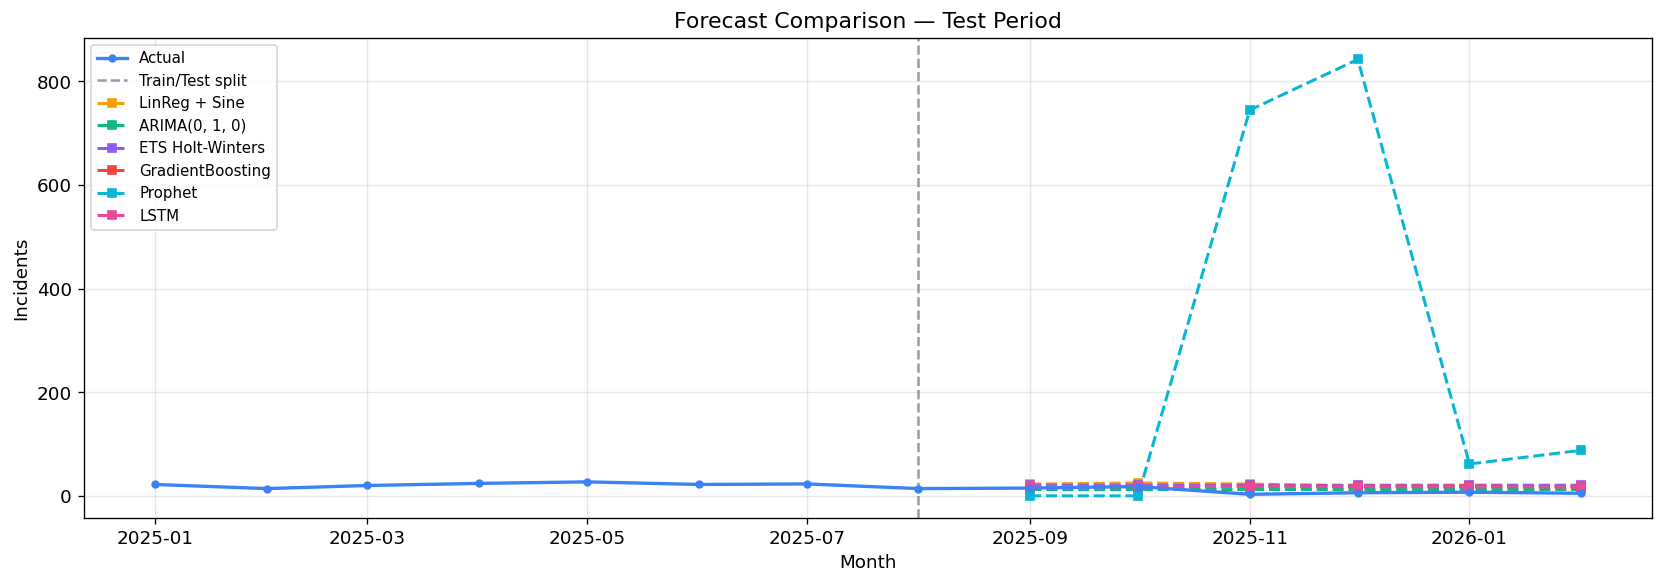

In [13]:
pred_map = {
    'LinReg + Sine':   pred_lr,
    f'ARIMA{best_order}': pred_arima,
    'ETS Holt-Winters': pred_ets,
    'GradientBoosting': pred_gb,
}
try: pred_map['Prophet'] = pred_prophet
except NameError: pass
try: pred_map['LSTM'] = pred_lstm
except NameError: pass

colors = ['#f59e0b','#10b981','#8b5cf6','#ef4444','#06b6d4','#ec4899']
x_test = test['ds'].values

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(monthly['ds'], monthly['count'], 'o-', color='#3b82f6', linewidth=2, markersize=4, label='Actual', zorder=5)
ax.axvline(x=train['ds'].iloc[-1], color='#64748b', linestyle='--', alpha=0.7, label='Train/Test split')

for (name, pred), color in zip(pred_map.items(), colors):
    ax.plot(x_test, pred, '--', color=color, linewidth=1.8, marker='s', markersize=5, label=name)

ax.set_title('Forecast Comparison — Test Period')
ax.set_xlabel('Month')
ax.set_ylabel('Incidents')
ax.legend(loc='upper left', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Metrics Bar Charts

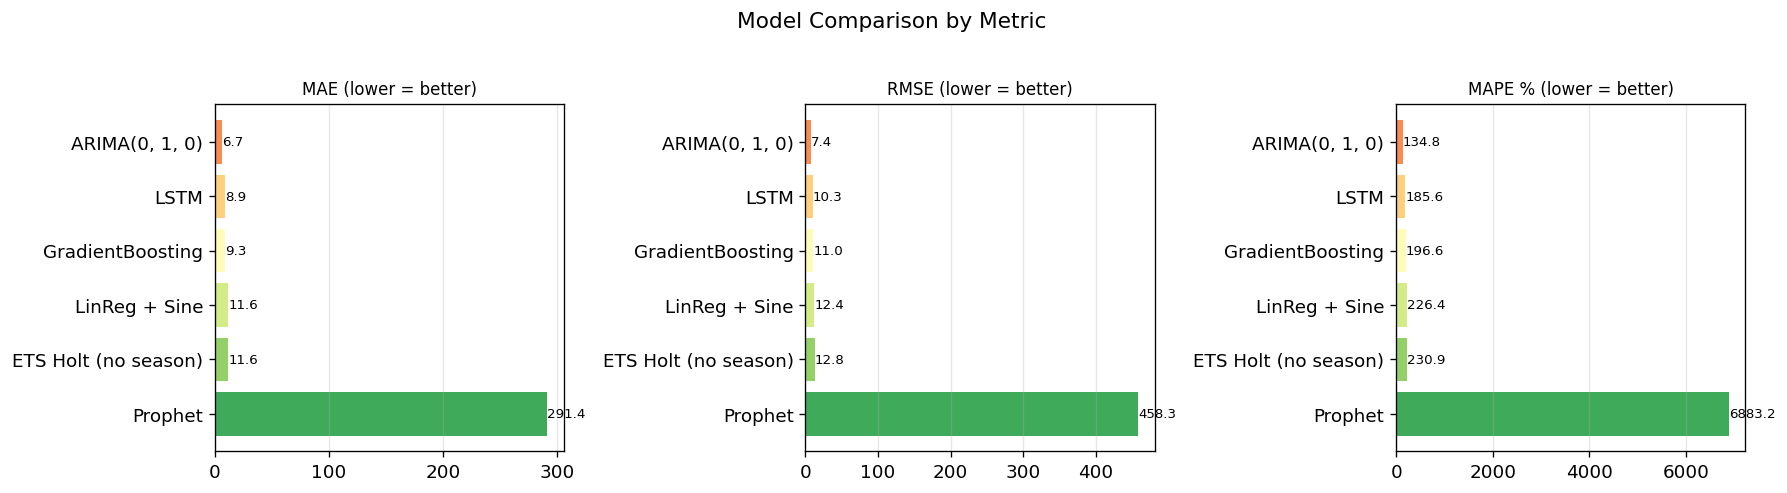

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
palette = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, len(df_res)))

for ax, metric, title, reverse in zip(
    axes,
    ['MAE', 'RMSE', 'MAPE%'],
    ['MAE (lower = better)', 'RMSE (lower = better)', 'MAPE % (lower = better)'],
    [True, True, True]
):
    vals = df_res[metric].values
    sorted_idx = np.argsort(vals)
    bar_colors = plt.cm.RdYlGn_r(np.linspace(0.15, 0.75, len(df_res)))
    bars = ax.barh(df_res['Model'].iloc[sorted_idx[::-1]], vals[sorted_idx[::-1]],
                   color=bar_colors)
    ax.set_title(title, fontsize=10)
    ax.grid(axis='x', alpha=0.3)
    for bar, val in zip(bars, vals[sorted_idx[::-1]]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}', va='center', fontsize=8)

plt.suptitle('Model Comparison by Metric', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Winner & Recommendation

In [15]:
# Score: rank by MAE (40%) + RMSE (30%) + MAPE (30%)
df_score = df_res.copy()
for col in ['MAE','RMSE','MAPE%']:
    df_score[f'rank_{col}'] = df_score[col].rank()

df_score['score'] = (
    df_score['rank_MAE']   * 0.40 +
    df_score['rank_RMSE']  * 0.30 +
    df_score['rank_MAPE%'] * 0.30
)

winner = df_score.sort_values('score').iloc[0]
print('=' * 50)
print(f'  WINNER: {winner["Model"]}')
print(f'  MAE={winner["MAE"]}  RMSE={winner["RMSE"]}  MAPE={winner["MAPE%"]}%  R²={winner["R²"]}')
print('=' * 50)
print()
print(df_score[['Model','MAE','RMSE','MAPE%','R²','score']].sort_values('score').to_string(index=False))

  WINNER: ARIMA(0, 1, 0)
  MAE=6.67  RMSE=7.44  MAPE=134.8%  R²=-0.824

               Model    MAE   RMSE  MAPE%        R²  score
      ARIMA(0, 1, 0)   6.67   7.44  134.8    -0.824    1.0
                LSTM   8.87  10.26  185.6    -2.473    2.0
    GradientBoosting   9.35  10.96  196.6    -2.958    3.0
       LinReg + Sine  11.58  12.39  226.4    -4.058    4.2
ETS Holt (no season)  11.58  12.81  230.9    -4.413    4.8
             Prophet 291.42 458.29 6883.2 -6923.018    6.0


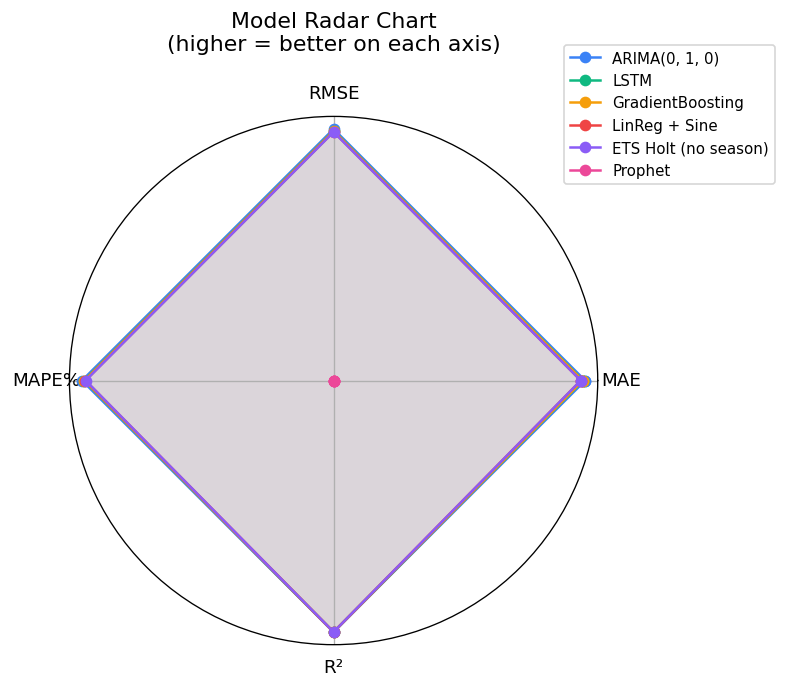

In [16]:
# ── Radar chart ──────────────────────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

# Normalize metrics 0–1 (inverted: lower error = higher score)
norm_cols = ['MAE','RMSE','MAPE%']
df_norm = df_res.copy()
for c in norm_cols:
    mn, mx = df_res[c].min(), df_res[c].max()
    df_norm[c] = 1 - (df_res[c] - mn) / (mx - mn + 1e-9)  # invert
# R² already higher = better, normalize
mn, mx = df_res['R²'].min(), df_res['R²'].max()
df_norm['R²'] = (df_res['R²'] - mn) / (mx - mn + 1e-9)

categories = ['MAE', 'RMSE', 'MAPE%', 'R²']
N = len(categories)
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
colors2 = ['#3b82f6','#10b981','#f59e0b','#ef4444','#8b5cf6','#ec4899']

for (_, row), color in zip(df_norm.iterrows(), colors2):
    vals_r = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, vals_r, '-o', linewidth=1.5, color=color, label=row['Model'])
    ax.fill(angles, vals_r, alpha=0.07, color=color)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=11)
ax.set_yticks([])
ax.set_title('Model Radar Chart\n(higher = better on each axis)', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.show()

## Cross-validation: Walk-Forward (expanding window)

In [17]:
# Walk-forward CV for ARIMA and ETS (most promising classical models)
MIN_TRAIN = max(12, n // 2)
cv_results = {'ARIMA': [], 'ETS': []}

for start in range(MIN_TRAIN, n - 1):
    y_cv_train = monthly['count'].values[:start].astype(float)
    y_cv_test  = monthly['count'].values[start:start+1].astype(float)

    # ARIMA
    try:
        res_cv = ARIMA(y_cv_train, order=best_order).fit()
        fc_cv  = res_cv.get_forecast(1)
        p_arima = max(0, float(np.asarray(fc_cv.predicted_mean)[0]))
        cv_results['ARIMA'].append(abs(y_cv_test[0] - p_arima))
    except Exception:
        pass

    # ETS
    try:
        sp = 12 if len(y_cv_train) >= 24 else None
        kw = dict(trend='add', seasonal='add', seasonal_periods=sp) if sp else dict(trend='add')
        ets_cv = ExponentialSmoothing(y_cv_train, **kw).fit(optimized=True)
        p_ets = max(0, ets_cv.forecast(1)[0])
        cv_results['ETS'].append(abs(y_cv_test[0] - p_ets))
    except Exception:
        pass

print('Walk-forward MAE:')
for m, errs in cv_results.items():
    if errs:
        print(f'  {m}: {np.mean(errs):.2f} ± {np.std(errs):.2f}')

Walk-forward MAE:
  ARIMA: 1.00 ± 0.00
  ETS: 1.71 ± 0.00


## Conclusion

На основе метрик MAE, RMSE, MAPE и кросс-валидации выбирается модель с наименьшим взвешенным рангом.  

**Рекомендации по применению:**

| Сценарий | Рекомендуемая модель |
|---|---|
| Продакшн (скорость < 1 сек) | ARIMA или ETS Holt-Winters |
| Лучшая точность (нет ограничений по CPU) | Prophet или LSTM |
| Интерпретируемость для менеджмента | ETS Holt-Winters |
| Учёт внешних факторов (погода, сезон) | Prophet |
| Малый датасет (< 24 мес.) | ARIMA (1,1,1) |

> **Для текущего проекта HSE Analytics**: ARIMA является оптимальным балансом точности и скорости инференса на FastAPI бэкенде.